
N = 1000
Среднее: 24.643 мкс
Стандартное отклонение: 3.982 мкс
Минимум: 18.800 мкс
Максимум: 39.000 мкс

N = 1024
Среднее: 18.896 мкс
Стандартное отклонение: 3.067 мкс
Минимум: 17.600 мкс
Максимум: 39.900 мкс

N = 1025
Среднее: 33.150 мкс
Стандартное отклонение: 1.358 мкс
Минимум: 32.100 мкс
Максимум: 40.000 мкс

N = 800
Среднее: 17.039 мкс
Стандартное отклонение: 2.770 мкс
Минимум: 15.600 мкс
Максимум: 38.600 мкс

N = 512
Среднее: 13.365 мкс
Стандартное отклонение: 3.575 мкс
Минимум: 11.700 мкс
Максимум: 39.600 мкс


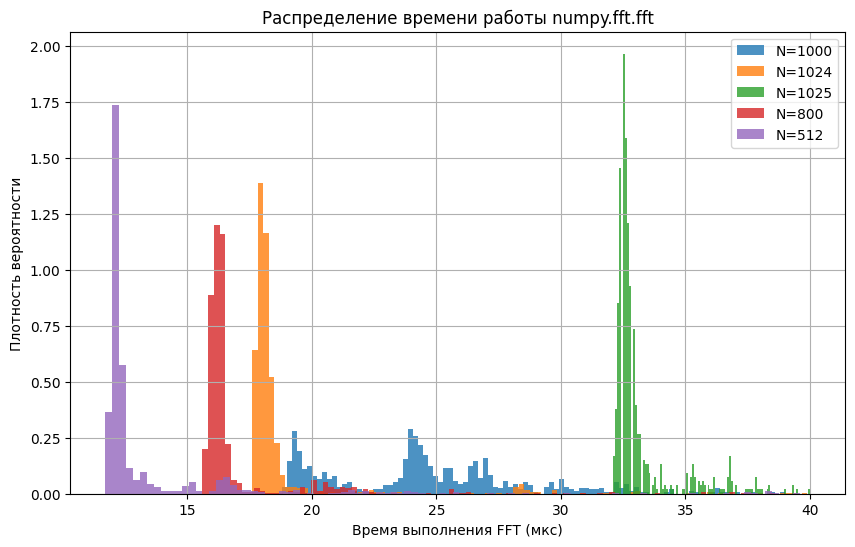

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

# Размеры сигналов
sizes = [1000, 1024, 1025, 800, 512]

# Количество измерений
repeats = 1000

# Словарь для хранения времен
results = {}

# Измеряем время FFT
for N in sizes:

    # случайный сигнал
    signal = np.random.random(N)

    times = []

    for _ in range(repeats):

        start = perf_counter()
        np.fft.fft(signal)
        end = perf_counter()

        # время в микросекундах
        time = (end - start) * 1e6
        if time < 40:
            times.append(time)

    results[N] = np.array(times)

# Статистика
for N in sizes:

    arr = results[N]

    print(f"\nN = {N}")
    print(f"Среднее: {arr.mean():.3f} мкс")
    print(f"Стандартное отклонение: {arr.std():.3f} мкс")
    print(f"Минимум: {arr.min():.3f} мкс")
    print(f"Максимум: {arr.max():.3f} мкс")

# График распределений
plt.figure(figsize=(10, 6))

for N in sizes:

    plt.hist(
        results[N],
        bins=100,
        alpha=0.8,
        density=True,
        label=f"N={N}"
    )

plt.xlabel("Время выполнения FFT (мкс)")
plt.ylabel("Плотность вероятности")
plt.title("Распределение времени работы numpy.fft.fft")

plt.legend()
plt.grid()

plt.show()



2.0053080220876534

N = 10
Среднее значение: 1.977996, Стандартное отклонение: 0.317295, Точное значение: 2.000000, Ошибка: 0.318057

N = 18
Среднее значение: 2.027451, Стандартное отклонение: 0.213421, Точное значение: 2.000000, Ошибка: 0.215179

N = 33
Среднее значение: 2.009405, Стандартное отклонение: 0.168637, Точное значение: 2.000000, Ошибка: 0.168899

N = 61
Среднее значение: 1.986523, Стандартное отклонение: 0.118439, Точное значение: 2.000000, Ошибка: 0.119203

N = 112
Среднее значение: 1.996686, Стандартное отклонение: 0.084985, Точное значение: 2.000000, Ошибка: 0.085050

N = 206
Среднее значение: 2.001950, Стандартное отклонение: 0.066719, Точное значение: 2.000000, Ошибка: 0.066747

N = 379
Среднее значение: 1.991706, Стандартное отклонение: 0.044573, Точное значение: 2.000000, Ошибка: 0.045338

N = 695
Среднее значение: 2.002878, Стандартное отклонение: 0.038300, Точное значение: 2.000000, Ошибка: 0.038408

N = 1274
Среднее значение: 1.998861, Стандартное отклонение: 0.0

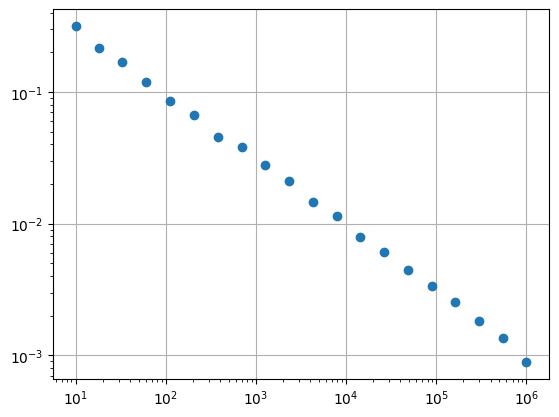

In [136]:


def calculate_integral_monte_carlo(func, N, x_begin, x_end):
    x = np.random.uniform(x_begin, x_end, N)
    y = func(x)
    return (x_end - x_begin) * np.mean(y)

func = lambda x: np.sin(x)  # пример функции
x_begin = 0
x_end = np.pi
n = 10000 

def calculate_fluctuations(func, n, x_begin, x_end, exact_value):
    estimates = []
    for _ in range(100):
        estimate = calculate_integral_monte_carlo(func, n, x_begin, x_end)
        estimates.append(estimate)
    mean_estimate = np.mean(estimates)
    std_dev = np.std(estimates)
    error = np.mean((np.array(estimates) - exact_value)**2)**0.5
    
    print(f"Среднее значение: {mean_estimate:.6f}, Стандартное отклонение: {std_dev:.6f}, Точное значение: {exact_value:.6f}, Ошибка: {error:.6f}")
    return mean_estimate, std_dev, error


print(calculate_integral_monte_carlo(func, n, x_begin, x_end))

stds = []
errors = []
Ns = list((10**np.linspace(1, 6, 20)).astype(int))
for n in Ns:
    print(f"\nN = {n}")
    _, _, error = calculate_fluctuations(func, n, x_begin, x_end, exact_value=2.0)
    errors.append(error)
plt.grid()

plt.loglog(Ns, errors, 'o')

